--- Matrix A Shape & Dimensions ---
Shape of A: (3, 3)
Dimensions: 2

Element at Row 2, Column 3:
2

Element-wise A * A:
[[4 1 1]
 [9 1 4]
 [4 1 4]]

Matrix Multiplication A @ A:
[[  3   0  -2]
 [ -7   0   5]
 [-11  -1   8]]

--- Solving Linear Equations ---
Solution using Inverse:
[[ -6.]
 [  7.]
 [-11.]]

Solution using np.linalg.solve:
[[ -6.]
 [  7.]
 [-11.]]

--- Pandas DataFrame ---
         Math  Statistics  Python
Ahmed      85          90      78
Mona       60          70      65
Ali        92          95      98
Sara       75          80      70
Omar       50          55      60
Nour       88          85      87
Youssef    72          75      74
Hana       95          92      96
Adam       68          65      70
Laila      80          82      85

--- Python Grades ---
Ahmed      78
Mona       65
Ali        98
Sara       70
Omar       60
Nour       87
Youssef    74
Hana       96
Adam       70
Laila      85
Name: Python, dtype: int64

--- Ahmed's Grades using loc ---
Math      

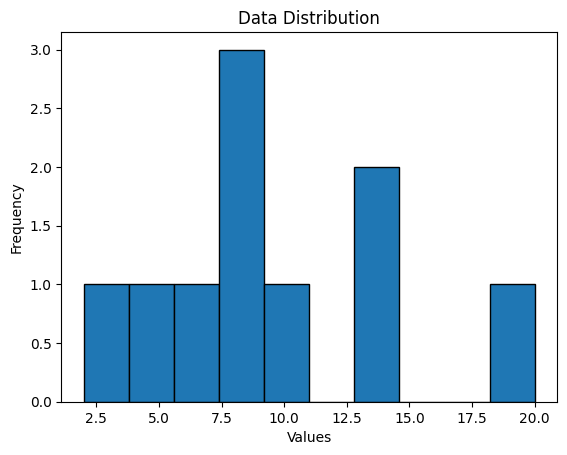

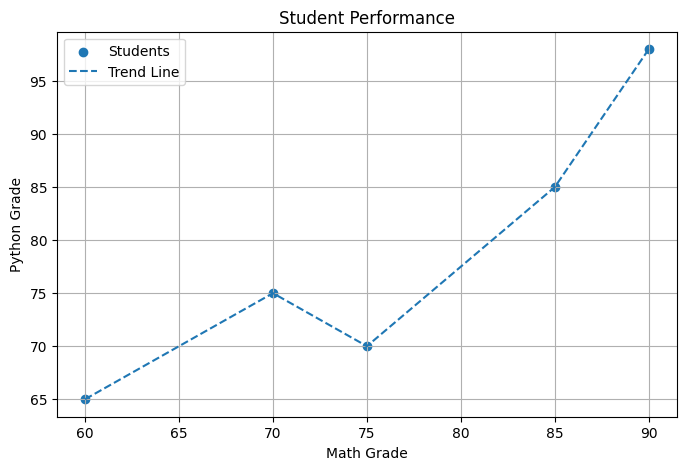

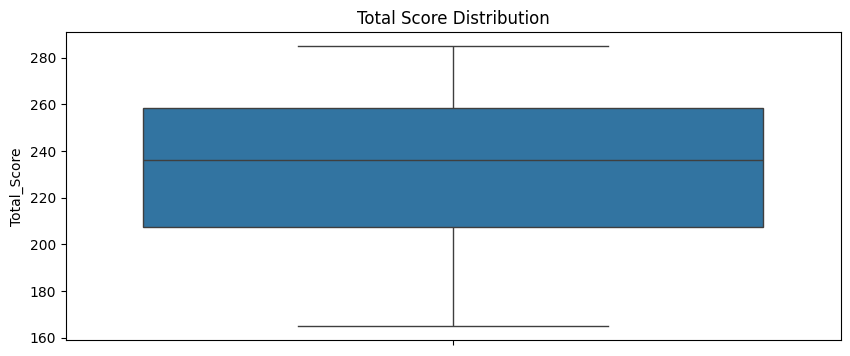

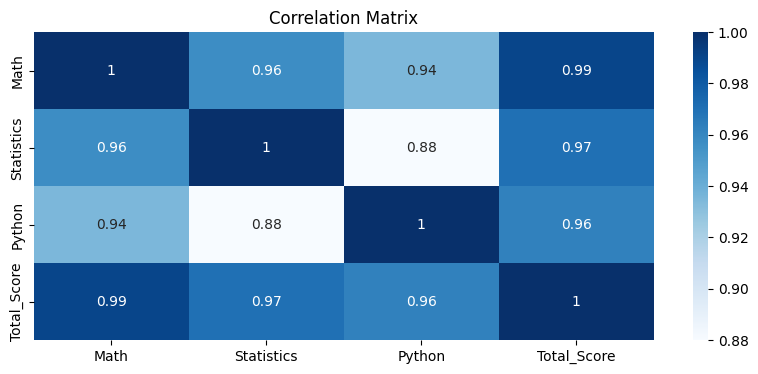


--- Train/Test Split ---
Training data:
[[85 90]
 [95 92]
 [92 95]
 [80 82]
 [50 55]
 [75 80]
 [72 75]]

Testing data:
[[68 65]
 [60 70]
 [88 85]]

--- Linear Regression Results ---
Predicted: [79.65412056 58.68299174 93.81686623]
Actual: [70 65 87]
R2 Score: 32.49011190611836

--- PyTorch Prediction ---
PyTorch Predicted output for x=5: 9.94


In [7]:
import numpy as np
import pandas as pd
import statistics as st
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.optim as optim


# NUMPY - MATRIX
A = np.array([
    [2, 1, -1],
    [-3, -1, 2],
    [-2, 1, 2]
])

B = np.array([
    [6],
    [-11],
    [-3]
])

print("--- Matrix A Shape & Dimensions ---")
print("Shape of A:", A.shape)
print("Dimensions:", A.ndim)

print("\nElement at Row 2, Column 3:")
print(A[1, 2])

print("\nElement-wise A * A:")
print(A * A)

print("\nMatrix Multiplication A @ A:")
print(np.dot(A, A))


# SOLVING SYSTEM OF LINEAR EQUATIONS
print("\n--- Solving Linear Equations ---")

A_inv = np.linalg.inv(A)
X_inv = np.dot(A_inv, B)

print("Solution using Inverse:")
print(X_inv)

X_solve = np.linalg.solve(A, B)

print("\nSolution using np.linalg.solve:")
print(X_solve)


# STUDENT DATA
data_matrix = np.array([
    [85, 90, 78],
    [60, 70, 65],
    [92, 95, 98],
    [75, 80, 70],
    [50, 55, 60],
    [88, 85, 87],
    [72, 75, 74],
    [95, 92, 96],
    [68, 65, 70],
    [80, 82, 85]
])

student_names = [
    'Ahmed',
    'Mona',
    'Ali',
    'Sara',
    'Omar',
    'Nour',
    'Youssef',
    'Hana',
    'Adam',
    'Laila'
]

subjects = [
    'Math',
    'Statistics',
    'Python'
]


# PANDAS DATAFRAME
df = pd.DataFrame(
    data=data_matrix,
    index=student_names,
    columns=subjects
)

print("\n--- Pandas DataFrame ---")
print(df)


# PANDAS - SELECT COLUMN
print("\n--- Python Grades ---")
print(df['Python'])


# PANDAS - LOC
print("\n--- Ahmed's Grades using loc ---")
print(df.loc['Ahmed'])


# PANDAS - ILOC
print("\n--- Mona's Statistics Grade using iloc ---")
print(df.iloc[1, 1])


# PANDAS - MEAN
print("\n--- Mean Grade for Each Subject ---")
print(df.mean(axis=0))


# PANDAS - TOTAL SCORE
df['Total_Score'] = df.sum(axis=1)

print("\n--- DataFrame with Total Scores ---")
print(df)


# PANDAS - FILTERING
print("\n--- Students with Math Grade > 70 ---")
print(df[df['Math'] > 70])


# STATISTICS
data = [10, 14, 5, 9, 2, 20, 6, 9, 14, 9]

print("\n--- Statistical Analysis ---")

print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Mode:", st.mode(data))
print("Standard Deviation:", np.std(data, ddof=1))


# MATPLOTLIB - HISTOGRAM
plt.hist(data, edgecolor='black')

plt.title("Data Distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()


# MATPLOTLIB - SCATTER
math_grades = np.array([60, 70, 75, 85, 90])
python_grades = np.array([65, 75, 70, 85, 98])

plt.figure(figsize=(8, 5))

plt.scatter(
    math_grades,
    python_grades,
    marker='o',
    label='Students'
)

plt.plot(
    math_grades,
    python_grades,
    linestyle='--',
    label='Trend Line'
)

plt.title('Student Performance')
plt.xlabel('Math Grade')
plt.ylabel('Python Grade')

plt.legend()
plt.grid(True)

plt.show()


# SEABORN - BOXPLOT
plt.figure(figsize=(10, 4))

sns.boxplot(y=df['Total_Score'])

plt.title('Total Score Distribution')

plt.show()


# SEABORN - HEATMAP
plt.figure(figsize=(10, 4))

sns.heatmap(
    df[['Math', 'Statistics', 'Python', 'Total_Score']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Matrix')

plt.show()


# SCIKIT-LEARN
X = df[['Math', 'Statistics']].values
y = df['Python'].values


# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\n--- Train/Test Split ---")

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)


# STANDARD SCALER

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# LINEAR REGRESSION
model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)


# PREDICTION AND R2 SCORE
y_pred = model.predict(X_test_scaled)

print("\n--- Linear Regression Results ---")

print("Predicted:", y_pred)

print("Actual:", y_test)

print(
    "R2 Score:",
    r2_score(y_test, y_pred) * 100
)


# PYTORCH - TENSORS
X_tensor = torch.tensor(
    [[1.0], [2.0], [3.0], [4.0]],
    dtype=torch.float32
)

y_tensor = torch.tensor(
    [[2.0], [4.0], [6.0], [8.0]],
    dtype=torch.float32
)


# SIMPLE NEURAL NETWORK
class SimpleNN(nn.Module):

    def __init__(self):
        super(SimpleNN, self).__init__()

        self.linear = nn.Linear(
            in_features=1,
            out_features=1
        )

    def forward(self, x):
        return self.linear(x)


model = SimpleNN()


# LOSS AND OPTIMIZER
criterion = nn.MSELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)


# TRAINING LOOP
for epoch in range(100):

    y_pred = model(X_tensor)

    loss = criterion(
        y_pred,
        y_tensor
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


# PYTORCH PREDICTION
test_val = torch.tensor(
    [[5.0]],
    dtype=torch.float32
)

predicted = model(test_val)

print("\n--- PyTorch Prediction ---")

print(
    f"PyTorch Predicted output for x=5: "
    f"{predicted.item():.2f}"
)